In [1]:
!pip install gensim

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.0 MB 326.8 kB/s eta 0:01:14
   ---------------------------------------- 0.2/24.0 MB 984.6 kB/s eta 0:00:25
   ---------------------------------------- 0.3/24.0 MB 1.5 MB/s eta 0:00:17
    --------------------------------------- 0.4/24.0 MB 1.7 MB/s eta 0:00:14
   - -------------------------------------- 0.8/24.0 MB 2.8 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/24.0 MB 4.5 MB/s eta 0:00:05
   ---- ----------------------------------- 2.4/24.0 MB 6.2 MB/s eta 0:00:04
   ----- ---------------------------------- 3.5/24.0 MB 7.9 MB/s eta 0:00:03
   ------- -------------------------------- 4.6/24.0 MB 9.3 MB/s eta 0:00:03
   --------- ---------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blis 1.0.1 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.2 requires numpy<2.1.0,>=2.0.0; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install plotly

   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.1 MB 262.6 kB/s eta 0:01:13
   ---------------------------------------- 0.0/19.1 MB 245.8 kB/s eta 0:01:18
   ---------------------------------------- 0.1/19.1 MB 435.7 kB/s eta 0:00:44
   ---------------------------------------- 0.2/19.1 MB 919.0 kB/s eta 0:00:21
    --------------------------------------- 0.4/19.1 MB 1.4 MB/s eta 0:00:14
   - -------------------------------------- 0.6/19.1 MB 1.9 MB/s eta 0:00:10
   -- ------------------------------------- 1.0/19.1 MB 2.7 MB/s eta 0:00:07
   --- ------------------------------------ 1.8/19.1 MB 4.3 MB/s eta 0:00:05
   ----- ---------------------------------- 2.7/19.1 MB 5.9 MB/s eta 0:00:03
   ------- --------


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
## importing dependencies
from gensim.models import Word2Vec, FastText
import pandas as pd
import re

from sklearn.decomposition import PCA

from matplotlib import pyplot as plt
import plotly.graph_objects as go

import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [9]:
sentences = [['i', 'like', 'apple', 'pie', 'for', 'dessert'],
           ['i', 'dont', 'drive', 'fast', 'cars'],
           ['data', 'science', 'is', 'fun'],
           ['chocolate', 'is', 'my', 'favorite'],
           ['my', 'favorite', 'movie', 'is', 'predator']]

In [33]:
# train word2vec model
w2v = Word2Vec(sentences, min_count = 1, vector_size =5, seed = 100)
print(w2v)

Word2Vec<vocab=19, vector_size=5, alpha=0.025>


In [18]:
print(w2v.wv['drive'])

[0.14623532 0.10140524 0.13515386 0.01525731 0.12701781]


In [22]:
words = list(w2v.wv.key_to_index.keys())
print(words)

['is', 'i', 'favorite', 'my', 'drive', 'like', 'apple', 'pie', 'for', 'dessert', 'dont', 'predator', 'fast', 'movie', 'data', 'science', 'fun', 'chocolate', 'cars']


In [23]:
print(len(words))

19


In [25]:
w2v.wv.key_to_index

{'is': 0,
 'i': 1,
 'favorite': 2,
 'my': 3,
 'drive': 4,
 'like': 5,
 'apple': 6,
 'pie': 7,
 'for': 8,
 'dessert': 9,
 'dont': 10,
 'predator': 11,
 'fast': 12,
 'movie': 13,
 'data': 14,
 'science': 15,
 'fun': 16,
 'chocolate': 17,
 'cars': 18}

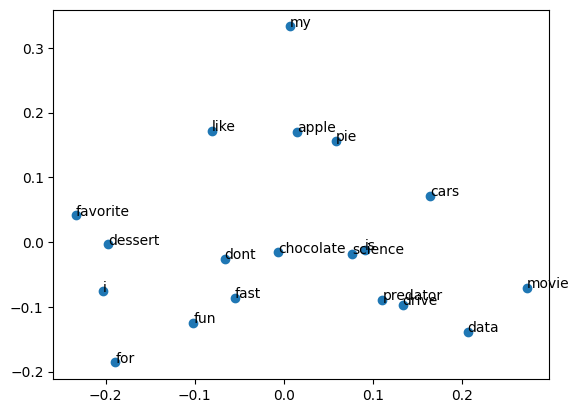

In [34]:
X = w2v.wv[w2v.wv.key_to_index.keys()]
pca = PCA(n_components = 2)

result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])

for i, word in enumerate(words):
    plt.annotate(word, xy = (result[i,0],result[i,1]))
plt.show()

In [35]:
df = pd.read_csv('./emails.csv')

In [36]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
